In [ ]:
# ==========================================
# Healthcare Risk Analytics Project
# Technologies:
# Python, Pandas, NumPy, Matplotlib
# MySQL, SQL, Power BI
# ==========================================

In [ ]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
import os

os.listdir('/content')

['.config', 'healthcare_dataset.csv', 'sample_data']

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving healthcare_dataset.csv to healthcare_dataset (1).csv


In [ ]:
df.columns
df.info()
df.describe()

NameError: name 'df' is not defined

In [ ]:
# Check missing values

df.isnull().sum()

# Convert column names to lowercase

df.columns = df.columns.str.lower()

In [ ]:
# Age distribution of patients

plt.figure(figsize=(10,5))

plt.hist(df['age'], bins=20)

plt.title("Age Distribution of Patients")

plt.xlabel("Age")
plt.ylabel("Number of Patients")

plt.show()

In [ ]:
# Count male and female patients

df['gender'].value_counts()

# Create gender distribution chart

df['gender'].value_counts().plot(kind='bar')

plt.title("Gender Distribution")

plt.show()

In [ ]:
# Analyze frequency of medical conditions

df['medical condition'].value_counts()

In [ ]:
# Create custom healthcare risk score

df['riskscore'] = (
    df['billing amount'] * df['age']
) / df['room number']

In [ ]:
# Function to classify patients into risk categories

def classify_risk(score):

    if score < 2000:
        return "Low"

    elif score < 5000:
        return "Medium"

    else:
        return "High"

# Apply risk classification

df['risklevel'] = df['riskscore'].apply(classify_risk)

In [ ]:
# Convert admission and discharge dates

df['date of admission'] = pd.to_datetime(
    df['date of admission']
)

df['discharge date'] = pd.to_datetime(
    df['discharge date']
)

In [ ]:
# Calculate total hospital stay days

df['stay_days'] = (
    df['discharge date']
    - df['date of admission']
).dt.days

In [ ]:
# Extract admission month

df['admission_month'] = df[
    'date of admission'
].dt.month

In [ ]:
# Create advanced healthcare risk score

df['advanced_risk_score'] = (
    df['billing amount']
    * df['stay_days']
    * df['age']
) / df['room number']

In [ ]:
# Export processed dataset for MySQL and Power BI

df.to_csv(
    'civicpulse_final_healthcare_analysis.csv',
    index=False
)

print("Export completed successfully")


  Healthcare Risk Analytics Project
  Technologies:
  Python, Pandas, NumPy, Matplotlib
  MySQL, SQL, Power BI
  

Import required libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Check available files and folders in Google Colab working directory

In [ ]:
import os

os.listdir('/content')

['.config', 'sample_data']

Upload dataset file from local computer into Google Colab

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving healthcare_dataset.csv to healthcare_dataset.csv


Load healthcare dataset into Pandas DataFrame

Display first 5 rows of dataset

In [ ]:
# Load healthcare dataset into Pandas DataFrame

import pandas as pd

df = pd.read_csv('healthcare_dataset.csv')

df.head()

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,DaNnY sMitH,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal
3,andrEw waTtS,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal
4,adrIENNE bEll,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal


Display dataset column names

In [ ]:
df.columns

Index(['Name', 'Age', 'Gender', 'Blood Type', 'Medical Condition',
       'Date of Admission', 'Doctor', 'Hospital', 'Insurance Provider',
       'Billing Amount', 'Room Number', 'Admission Type', 'Discharge Date',
       'Medication', 'Test Results'],
      dtype='object')

Display dataset information

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55500 entries, 0 to 55499
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Name                55500 non-null  object 
 1   Age                 55500 non-null  int64  
 2   Gender              55500 non-null  object 
 3   Blood Type          55500 non-null  object 
 4   Medical Condition   55500 non-null  object 
 5   Date of Admission   55500 non-null  object 
 6   Doctor              55500 non-null  object 
 7   Hospital            55500 non-null  object 
 8   Insurance Provider  55500 non-null  object 
 9   Billing Amount      55500 non-null  float64
 10  Room Number         55500 non-null  int64  
 11  Admission Type      55500 non-null  object 
 12  Discharge Date      55500 non-null  object 
 13  Medication          55500 non-null  object 
 14  Test Results        55500 non-null  object 
dtypes: float64(1), int64(2), object(12)
memory usage: 6.4

Display statistical summary

In [ ]:
df.describe()

,Age,Billing Amount,Room Number
count,55500.000000,55500.000000,55500.000000
mean,51.539459,25539.316097,301.134829
std,19.602454,14211.454431,115.243069
min,13.000000,-2008.492140,101.000000
25%,35.000000,13241.224652,202.000000
50%,52.000000,25538.069376,302.000000
75%,68.000000,37820.508436,401.000000
max,89.000000,52764.276736,500.000000


Check missing values in dataset

In [ ]:
df.isnull().sum()

,0
Name,0
Age,0
Gender,0
Blood Type,0
Medical Condition,0
Date of Admission,0
Doctor,0
Hospital,0
Insurance Provider,0
Billing Amount,0


Convert column names to lowercase


    Display updated column names
---



In [ ]:
df.columns = df.columns.str.lower()

df.columns

Index(['name', 'age', 'gender', 'blood type', 'medical condition',
       'date of admission', 'doctor', 'hospital', 'insurance provider',
       'billing amount', 'room number', 'admission type', 'discharge date',
       'medication', 'test results'],
      dtype='object')

Create age distribution histogram

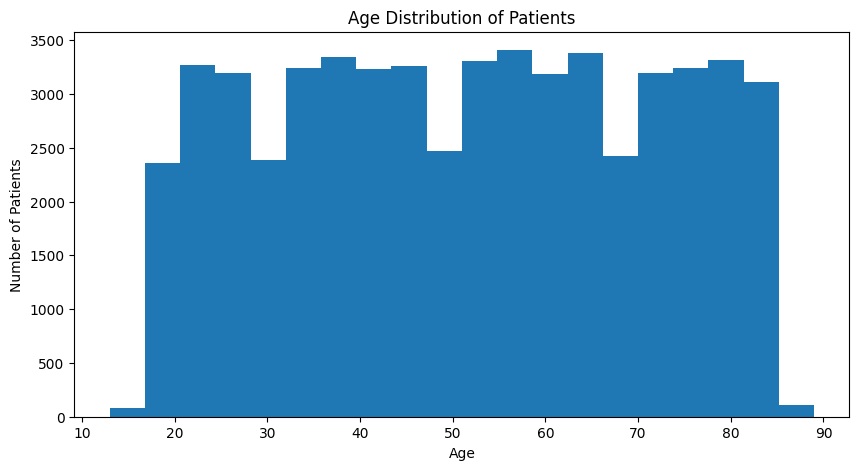

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.hist(df['age'], bins=20)

plt.title("Age Distribution of Patients")

plt.xlabel("Age")
plt.ylabel("Number of Patients")

plt.show()

Count total patients by gender

In [ ]:
df['gender'].value_counts()

,count
gender,
Male,27774
Female,27726


Create gender distribution bar chart

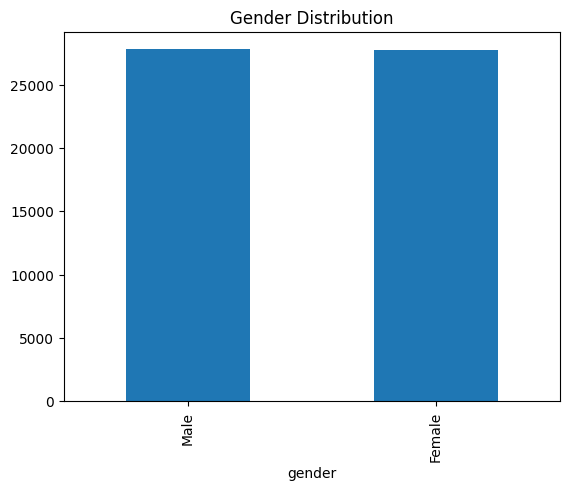

In [ ]:
df['gender'].value_counts().plot(kind='bar')

plt.title("Gender Distribution")

plt.show()

Count total patients by medical condition

In [ ]:
df['medical condition'].value_counts()

,count
medical condition,
Arthritis,9308
Diabetes,9304
Hypertension,9245
Obesity,9231
Cancer,9227
Asthma,9185


Create medical condition distribution chart

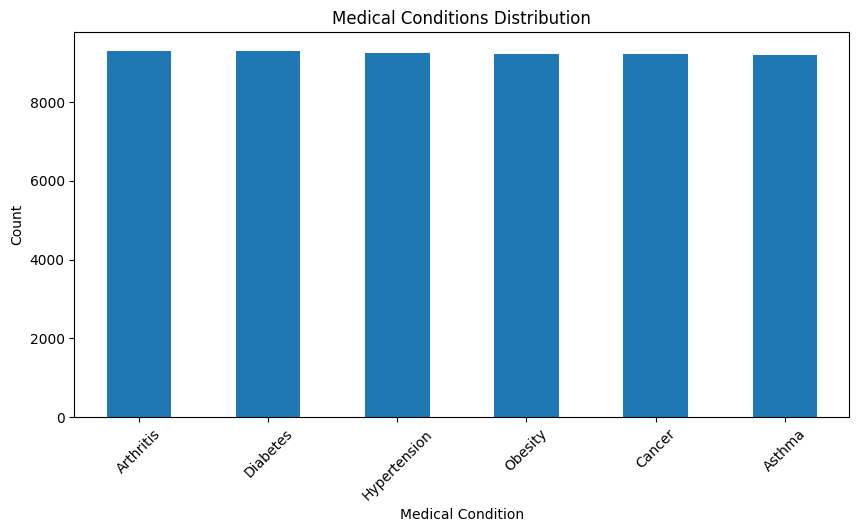

In [ ]:
df['medical condition'].value_counts().plot(
    kind='bar',
    figsize=(10,5)
)

plt.title("Medical Conditions Distribution")

plt.xlabel("Medical Condition")
plt.ylabel("Count")

plt.xticks(rotation=45)

plt.show()

Display billing amount statistical summary

In [ ]:
df['billing amount'].describe()

,billing amount
count,55500.000000
mean,25539.316097
std,14211.454431
min,-2008.492140
25%,13241.224652
50%,25538.069376
75%,37820.508436
max,52764.276736


Filter patients with billing amount greater than 40000

Display first 5 high billing records

In [ ]:
high_bill = df[df['billing amount'] > 40000]

high_bill.head()

,name,age,gender,blood type,medical condition,date of admission,doctor,hospital,insurance provider,billing amount,room number,admission type,discharge date,medication,test results
5,EMILY JOHNSOn,36,Male,A+,Asthma,2023-12-20,Taylor Newton,Nunez-Humphrey,UnitedHealthcare,48145.110951,389,Urgent,2023-12-24,Ibuprofen,Normal
7,CHrisTInA MARtinez,20,Female,A+,Cancer,2021-12-28,Suzanne Thomas,"Powell Robinson and Valdez,",Cigna,45820.462722,277,Emergency,2022-01-07,Paracetamol,Inconclusive
8,JASmINe aGuIlaR,82,Male,AB+,Asthma,2020-07-01,Daniel Ferguson,Sons Rich and,Cigna,50119.222792,316,Elective,2020-07-14,Aspirin,Abnormal
12,connOR HANsEn,75,Female,A+,Diabetes,2019-12-12,Kenneth Fletcher,"Powers Miller, and Flores",Cigna,43282.283358,134,Emergency,2019-12-28,Penicillin,Abnormal
14,bROOkE brady,44,Female,AB+,Cancer,2021-10-08,Roberta Stewart,Morris-Arellano,UnitedHealthcare,40701.599227,182,Urgent,2021-10-13,Paracetamol,Normal


In [ ]:
df['riskscore'] = (
    df['billing amount'] * df['age']
) / df['room number']

df[['age', 'billing amount', 'room number', 'riskscore']].head()

,age,billing amount,room number,riskscore
0,30,18856.281306,328,1724.659876
1,62,33643.327287,265,7871.269026
2,76,27955.096079,205,10363.840498
3,28,37909.782410,450,2358.830906
4,43,14238.317814,458,1336.785297


In [ ]:
def classify_risk(score):

    if score < 2000:
        return "Low"

    elif score < 5000:
        return "Medium"

    else:
        return "High"

df['risklevel'] = df['riskscore'].apply(classify_risk)

df[['riskscore', 'risklevel']].head()

,riskscore,risklevel
0,1724.659876,Low
1,7871.269026,High
2,10363.840498,High
3,2358.830906,Medium
4,1336.785297,Low


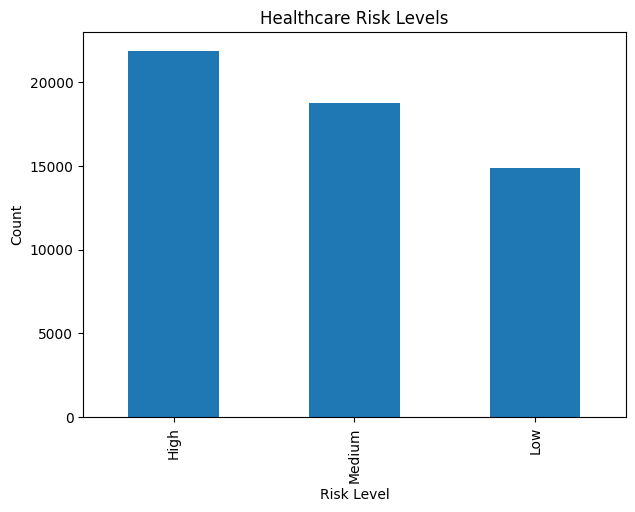

In [ ]:
df['risklevel'].value_counts().plot(
    kind='bar',
    figsize=(7,5)
)

plt.title("Healthcare Risk Levels")

plt.xlabel("Risk Level")
plt.ylabel("Count")

plt.show()

In [ ]:
df['date of admission'] = pd.to_datetime(
    df['date of admission']
)

df['discharge date'] = pd.to_datetime(
    df['discharge date']
)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55500 entries, 0 to 55499
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   name                55500 non-null  object        
 1   age                 55500 non-null  int64         
 2   gender              55500 non-null  object        
 3   blood type          55500 non-null  object        
 4   medical condition   55500 non-null  object        
 5   date of admission   55500 non-null  datetime64[ns]
 6   doctor              55500 non-null  object        
 7   hospital            55500 non-null  object        
 8   insurance provider  55500 non-null  object        
 9   billing amount      55500 non-null  float64       
 10  room number         55500 non-null  int64         
 11  admission type      55500 non-null  object        
 12  discharge date      55500 non-null  datetime64[ns]
 13  medication          55500 non-null  object    

In [ ]:
df['stay_days'] = (
    df['discharge date']
    - df['date of admission']
).dt.days

df[['date of admission',
    'discharge date',
    'stay_days']].head()

,date of admission,discharge date,stay_days
0,2024-01-31,2024-02-02,2
1,2019-08-20,2019-08-26,6
2,2022-09-22,2022-10-07,15
3,2020-11-18,2020-12-18,30
4,2022-09-19,2022-10-09,20


In [ ]:
condition_stay = df.groupby(
    'medical condition'
)['stay_days'].mean()

condition_stay

,stay_days
medical condition,
Arthritis,15.517404
Asthma,15.696570
Cancer,15.495827
Diabetes,15.422936
Hypertension,15.458626
Obesity,15.464305


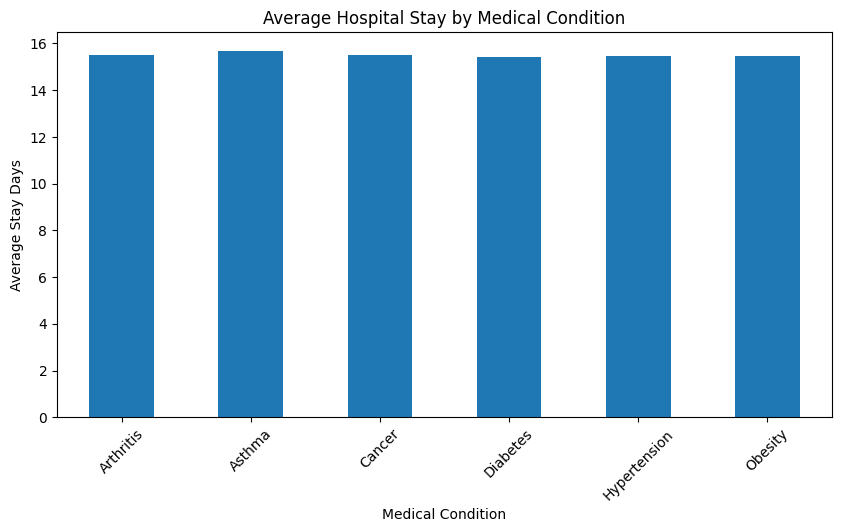

In [ ]:
condition_stay.plot(
    kind='bar',
    figsize=(10,5)
)

plt.title("Average Hospital Stay by Medical Condition")

plt.xlabel("Medical Condition")
plt.ylabel("Average Stay Days")

plt.xticks(rotation=45)

plt.show()

In [ ]:
df['admission_month'] = df[
    'date of admission'
].dt.month

df['admission_month'].head()

,admission_month
0,1
1,8
2,9
3,11
4,9


In [ ]:
monthly_admissions = df[
    'admission_month'
].value_counts().sort_index()

monthly_admissions

,count
admission_month,
1,4692
2,4255
3,4672
4,4518
5,4599
6,4699
7,4812
8,4832
9,4546


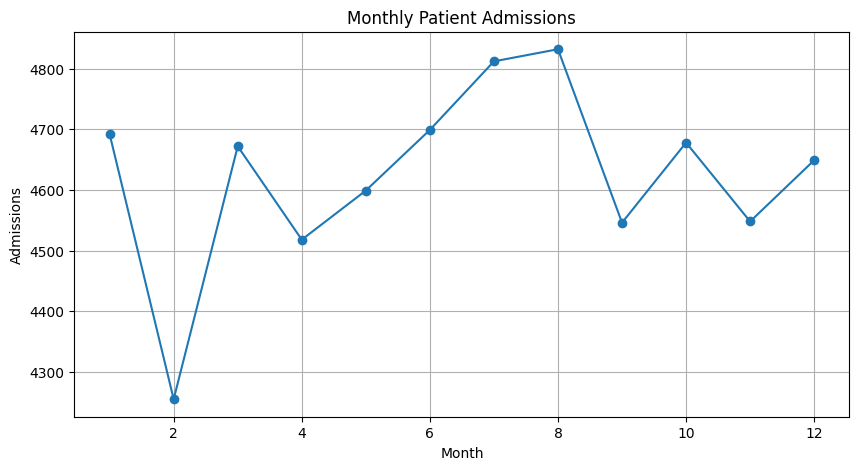

In [ ]:
monthly_admissions.plot(
    kind='line',
    figsize=(10,5),
    marker='o'
)

plt.title("Monthly Patient Admissions")

plt.xlabel("Month")
plt.ylabel("Admissions")

plt.grid(True)

plt.show()

In [ ]:
df['insurance provider'].value_counts()

,count
insurance provider,
Cigna,11249
Medicare,11154
UnitedHealthcare,11125
Blue Cross,11059
Aetna,10913


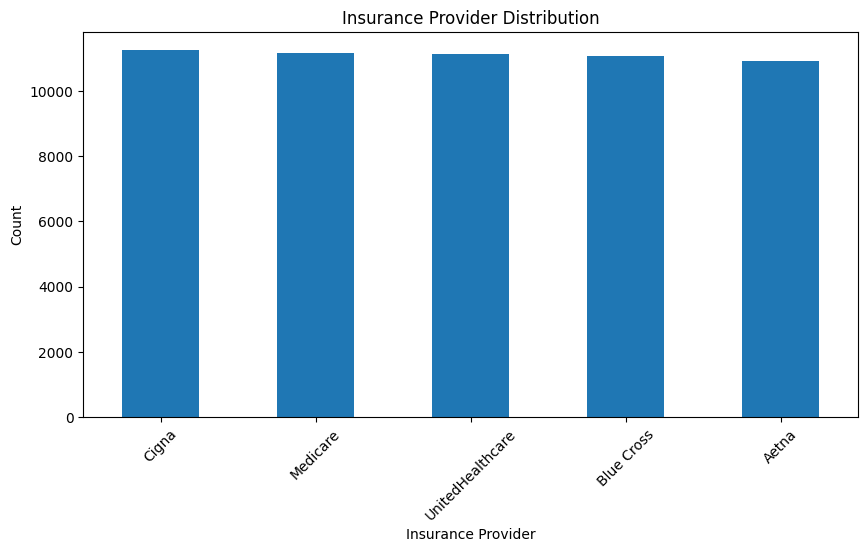

In [ ]:
df['insurance provider'].value_counts().plot(
    kind='bar',
    figsize=(10,5)
)

plt.title("Insurance Provider Distribution")

plt.xlabel("Insurance Provider")
plt.ylabel("Count")

plt.xticks(rotation=45)

plt.show()

In [ ]:
df['advanced_risk_score'] = (
    df['billing amount']
    * df['stay_days']
    * df['age']
) / df['room number']

df[['advanced_risk_score']].head()

,advanced_risk_score
0,3449.319751
1,47227.614153
2,155457.607463
3,70764.927165
4,26735.705939


In [ ]:
def advanced_risk(score):

    if score < 10000:
        return "Low"

    elif score < 50000:
        return "Medium"

    else:
        return "High"

df['advanced_risk_level'] = df[
    'advanced_risk_score'
].apply(advanced_risk)

df[['advanced_risk_score',
    'advanced_risk_level']].head()

,advanced_risk_score,advanced_risk_level
0,3449.319751,Low
1,47227.614153,Medium
2,155457.607463,High
3,70764.927165,High
4,26735.705939,Medium


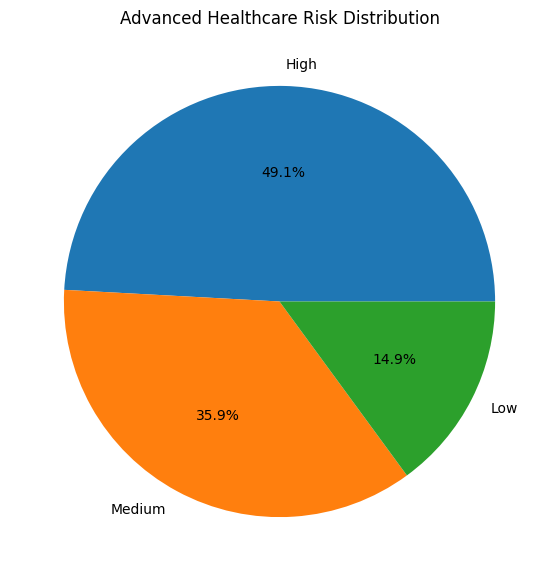

In [ ]:
df['advanced_risk_level'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    figsize=(7,7)
)

plt.title("Advanced Healthcare Risk Distribution")

plt.ylabel("")

plt.show()

In [ ]:
df['risklevel'] = df['riskscore'].apply(classify_risk)

df[['riskscore', 'risklevel']].head()

,riskscore,risklevel
0,1724.659876,Low
1,7871.269026,High
2,10363.840498,High
3,2358.830906,Medium
4,1336.785297,Low


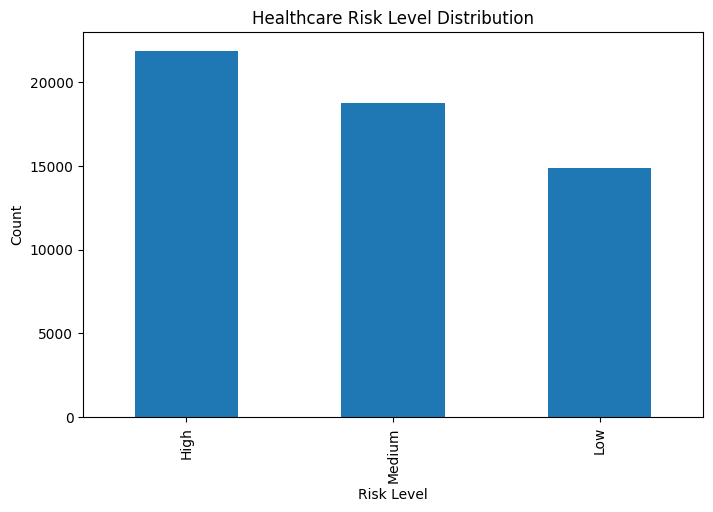

In [ ]:
df['risklevel'].value_counts().plot(
    kind='bar',
    figsize=(8,5)
)

plt.title("Healthcare Risk Level Distribution")

plt.xlabel("Risk Level")
plt.ylabel("Count")

plt.show()

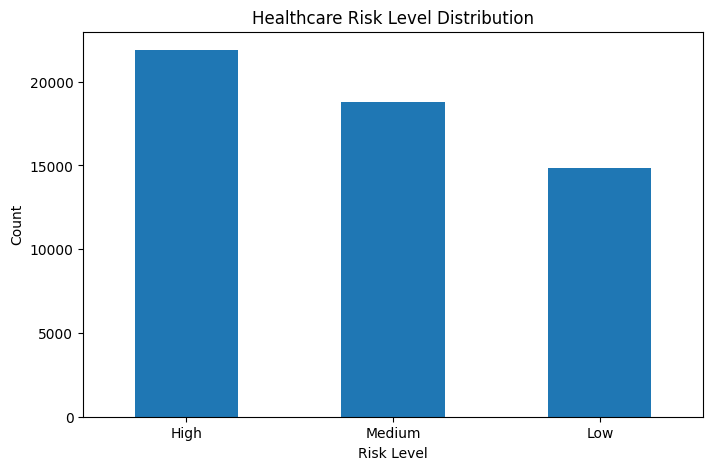

In [ ]:
df['risklevel'].value_counts().plot(
    kind='bar',
    figsize=(8,5)
)

plt.title("Healthcare Risk Level Distribution")

plt.xlabel("Risk Level")
plt.ylabel("Count")

plt.xticks(rotation=0)

plt.show()

In [ ]:
df.to_csv(
    'civicpulse_final_healthcare_analysis.csv',
    index=False
)

print("Export completed successfully")

Export completed successfully


In [ ]:
from google.colab import files

files.download(
    'civicpulse_final_healthcare_analysis.csv'
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>